# GROUP 2 CODE | MATH 451
Members: Amiri, Ebru, Madison, Cailyn \
https://github.com/AmiriHayes/rockphysicsproject \
[Link to Research Notebook](https://docs.google.com/document/d/1Imp-BBaWYbqmGOgQ5amiGeykf2N4QkyHTzvVvJPT-b8/edit?usp=sharing)

## __Notebook Goals:__

1 - Download existing & create simulated 3D rock topology data  [✓] \
2 - Simplify dataset using PoreSPY SNOW2 (into a graph network) [✓] \
3 - Predict permeability (fluid flow) on datasets using OpenPNM [✓] \
4 - Use machine learning to map representation to permeability \
* https://chatgpt.com/share/67c10964-8b3c-8004-9dbb-f566bc51a04c \
     -  Method 1: Try Node2Vec and Regular Deep Neural Network \
     -  Method 2: Try GCN: Graph Convolutional Networks \
     -  Method 3: Try MPNN: Message-Passing Neural Network \

## __Resources:__
Our Explanation of the PoreSPY SNOW2 Reduction Method:
- https://docs.google.com/presentation/d/1SSHW31IZ6fWqkfT2cLFDcU22-vQ2aC4XyXFaqe7JiCk/edit?usp=sharing
- [SNOW2 Research Paper](https://docs.google.com/document/d/1Imp-BBaWYbqmGOgQ5amiGeykf2N4QkyHTzvVvJPT-b8/edit?usp=sharing)

## __Installation:__
To install, run "pip install -r requirements.txt" in terminal \
Note: "pip install git+https://github.com/PMEAL/porespy.git@dev" installs latest porespy! \

## __Code References:__
1. polydisperse_spheres: https://porespy.org/examples/generators/reference/polydisperse_spheres.html
2. open_pnm_to_im: https://porespy.org/modules/generated/generated/porespy.io.openpnm_to_im.html
3. predict fluid flow: https://openpnm.org/examples/applications/network_extraction.html

## __Dataset References:__
1. Berea Sandstone: https://www.digitalrocksportal.org/projects/317
2.


# retrieve & simulate dataset (1/4)

In [ ]:
# imports:

!pip install porespy
import numpy as np
import pandas as pd
import porespy as ps
import openpnm as op
import matplotlib.pyplot as plt
from tqdm import tqdm

ps.visualization.set_mpl_style()
np.random.seed(10)

from google.colab import drive
drive.mount('/content/drive')

In [3]:
# retrieve & simulate rock topology data:

with open('/content/drive/My Drive/Berea_2d25um_binary.raw', 'rb') as f:
  binary_data = f.read()

im_bereasandstone = np.frombuffer(binary_data, dtype=np.uint8)
im_bereasandstone = im_bereasandstone.reshape((1000, 1000, 1000))
im_simulation = ps.generators.blobs(shape=[100,100,100], porosity=0.6, blobiness=2)

print(f'Simulation Data - Size: {int((im_simulation.size)**(1/3))+1}^3, Dimensions: {im_simulation.ndim}')
print(f'Sandstone Data - Size: {int((im_bereasandstone.size)**(1/3))+1}^3, Dimensions: {im_bereasandstone.ndim}')

Simulation Data - Size: 100^3, Dimensions: 3
Sandstone Data - Size: 1000^3, Dimensions: 3


# reduce to graph network + visualize (2/4)

Simulated Data:


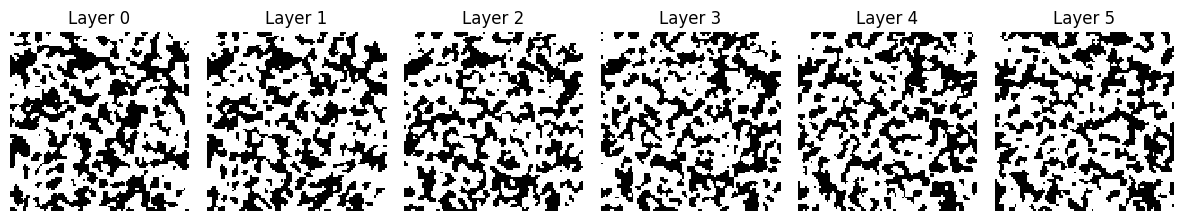

In [8]:
# Loop through the first n layers before conversion and plot them

layers_visualized = 6
fig, axes = plt.subplots(1, layers_visualized, figsize=(12, 4))

for i in range(layers_visualized):
    axes[i].imshow(im_simulation[i, :, :], cmap='gray')
    axes[i].set_title(f'Layer {i}')
    axes[i].axis('off')

print("Simulated Data:")
plt.tight_layout()
plt.show()

Real Rock Data:


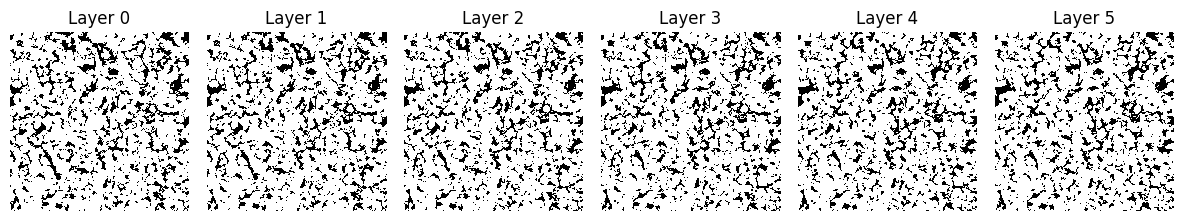

In [5]:
layers_visualized = 6
fig, axes = plt.subplots(1, layers_visualized, figsize=(12, 4))

for i in range(layers_visualized):
    axes[i].imshow(im_bereasandstone[i, :, :], cmap='gray')
    axes[i].set_title(f'Layer {i}')
    axes[i].axis('off')

print("Real Rock Data:")
plt.tight_layout()
plt.show()

235it [00:02, 85.48it/s]
245it [00:02, 86.86it/s]
254it [00:02, 87.26it/s]
265it [00:02, 93.25it/s]
290it [00:03, 106.34it/s]
302it [00:03, 108.79it/s]

81it [00:00, 78.89it/s]
0it [00:00, ?it/s]
15it [00:00, 135.45it/s]
31it [00:00, 140.65it/s]
46it [00:00, 123.70it/s]
59it [00:00, 124.17it/s]
74it [00:00, 131.15it/s]
94it [00:00, 151.07it/s]
110it [00:00, 149.19it/s]
126it [00:00, 150.16it/s]
142it [00:01, 139.04it/s]
157it [00:01, 139.38it/s]
173it [00:01, 141.53it/s]
252it [00:02, 145.52it/s]
203it [00:01, 139.39it/s]
286it [00:02, 149.31it/s]
218it [00:01, 139.64it/s]
259it [00:01, 171.36it/s]
                         
29it [00:00, 288.66it/s]
0it [00:00, ?it/s]
24it [00:00, 235.39it/s]
69it [00:00, 178.05it/s]
88it [00:00, 171.28it/s]
106it [00:00, 160.65it/s]
123it [00:00, 151.84it/s]
139it [00:00, 146.65it/s]
154it [00:00, 142.43it/s]
169it [00:01, 136.07it/s]
183it [00:01, 134.40it/s]
197it [00:01, 134.32it/s]
253it [00:01, 160.32it/s]
211it [00:01, 125.69it/s]
294it [00:01, 1

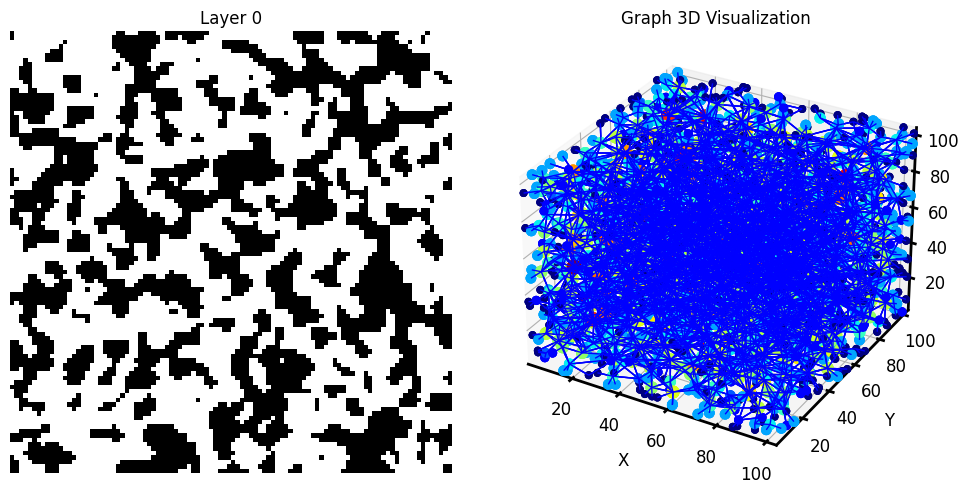

In [9]:
# convert to openim graph network:

snow_output = ps.networks.snow2(im_simulation, voxel_size=1)
pn = op.io.network_from_porespy(snow_output.network)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    ax = axes[i]
    ax.imshow(im_simulation[i, :, :].T, cmap=plt.cm.bone)

    op.visualization.plot_coordinates(ax=ax, network=pn,
                                      size_by=pn["pore.inscribed_diameter"],
                                      color_by=pn["pore.inscribed_diameter"],
                                      markersize=100)

    op.visualization.plot_connections(network=pn, ax=ax)
    if i == 0: ax.set_title(f'Layer {i}')
    if i == 1: ax.set_title(f'Graph 3D Visualization')
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Compare Sizes of Full & Reduced Data

im_size = im_bereasandstone.nbytes
print(f"Size of the original 3D matrix: {im_size / (1_000**3):.2f} GB")

snow_output = ps.networks.snow2(im_bereasandstone, voxel_size=1)
pn = op.io.network_from_porespy(snow_output.network)

import sys
network_size = sum(sys.getsizeof(arr) for arr in pn.keys() if isinstance(arr, np.ndarray))
print(f"Size of the graph representation: {network_size / (1024**3):.4f} GB")



# predict permeability using OpenPNM (3/4)

In [ ]:
data = {
    'shape': {
        'x': im_bereasandstone.shape[0],
        'y': im_bereasandstone.shape[1],
        'z': im_bereasandstone.shape[2],
    },
    'resolution': 5e-6,
    'porosity': 18.96,
    'permeability': {
        'Kx': 1360,
        'Ky': 1304,
        'Kz': 1193,
        'Kave': 1286,
    },
    'formation factor': {
        'Fx': 23.12,
        'Fy': 23.99,
        'Fz': 25.22,
        'Fave': 24.08,
    },
}

In [ ]:
# define network statistics

pn['pore.diameter'] = pn['pore.equivalent_diameter']
pn['throat.diameter'] = pn['throat.inscribed_diameter']
pn['throat.spacing'] = pn['throat.total_length']

pn.add_model(propname='throat.hydraulic_size_factors',
             model=op.models.geometry.hydraulic_size_factors.pyramids_and_cuboids)
pn.add_model(propname='throat.diffusive_size_factors',
             model=op.models.geometry.diffusive_size_factors.pyramids_and_cuboids)
pn['throat.hydraulic_conductance'] = pn['throat.diameter'] / pn['throat.spacing']
pn.regenerate_models()

In [ ]:
# check network is valid

h = op.utils.check_network_health(pn)
print(h)

op.topotools.trim(network=pn, pores=h['disconnected_pores'])
h = op.utils.check_network_health(pn)
print(h)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
―――――――――――――――――――――――――――――――――――――――――――――――――――――

In [ ]:
# define necessary gas / liquid properties and physics models

gas = op.phase.Phase(network=pn)
gas['pore.diffusivity'] = 1.0
gas['pore.viscosity'] = 1.0
gas['throat.entry_pressure'] = 0
gas['throat.surface_tension'] = 1.0
gas['throat.contact_angle'] = 0

gas.add_model(propname="pore.viscosity", model=op.models.misc.constant, value=1.0)
gas.add_model(propname="pore.diffusivity", model=op.models.misc.constant, value=1.0)
gas.add_model(
    propname="throat.diffusive_conductance",
    model=op.models.misc.constant, value=1.0
)

In [ ]:
# calculate the flow through simulated dataset

fd = op.algorithms.FickianDiffusion(network=pn, phase=gas)
fd.set_value_BC(pores=pn.pores('xmin'), values=1.0)
fd.set_value_BC(pores=pn.pores('xmax'), values=0.0)
fd.run()

dC = 1.0
L = (data['shape']['x'] + 6) * data['resolution']
A = data['shape']['y'] * data['shape']['z'] * data['resolution']**2
Deff = fd.rate(pores=pn.pores('xmin')) * (L / A) / dC
F = 1 / Deff

print(f"The Formation factor of the extracted network is {F[0]}")
print(f"This compares to a value of {data['formation factor']['Fx']} from DNS")
# np.testing.assert_allclose(F, data['formation factor']['Fx'], rtol=0.09)

The Formation factor of the extracted network is 0.000283744132145742
This compares to a value of 23.12 from DNS


In [ ]:
sf = op.algorithms.StokesFlow(network=pn, phase=gas)
sf.set_value_BC(pores=pn.pores('xmin'), values=1.0)
sf.set_value_BC(pores=pn.pores('xmax'), values=0.0)
sf.run()
dP = 1.0
L = (data['shape']['x'] + 6)*data['resolution']
A = data['shape']['y']*data['shape']['z']*data['resolution']**2
K = sf.rate(pores=pn.pores('xmin'))*(L/A)/dP*1e12
print(f'Permeability coefficient is {K[0]} Darcy')
print(f"The compares to a value of {data['permeability']['Kx']/1000} from DNS")

Permeability coefficient is 1235482649625293.8 Darcy
The compares to a value of 1.36 from DNS


# train a model to learn f(network) == 'permeability' (4/4)

In [ ]:
# IDEA NUMBER 1: Try Node2Vec and Regular Deep Neural Network



In [ ]:
# IDEA NUMBER 2: Try GCN: Graph Convolutional Networks



In [ ]:
# IDEA NUMBER 3: Try MPNN: Message-Passing Neural Network

